# Image Classifier 
## Training deep neural network with less data using bottleneck features

Importing necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
from keras.preprocessing.image import ImageDataGenerator
from keras import optimizers
from keras.models import Sequential
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D
from keras.layers import Activation, Dropout, Flatten, Dense

# Forcing it to use theono as the backend
from keras import backend as K
K.set_image_dim_ordering('th')

np.random.seed(1234)

Using Theano backend.


In [2]:
# All parameters

folder = 'data/flowers/'
train_data_dir = folder+'train'
validation_data_dir = folder+'validation'

nb_class = 2
img_width, img_height = 500, 500

Train_bottleneck = False

# bottleneck training parameters
nb_filters = 32
batch_size = 32
n_epoch = 50

In [3]:
def load_vgg16model(weights_path):

    model = Sequential()
    model.add(ZeroPadding2D((1, 1), input_shape=(3, img_width, img_height)))

    model.add(Convolution2D(64, 3, 3, activation='relu', name='conv1_1'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(64, 3, 3, activation='relu', name='conv1_2'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(128, 3, 3, activation='relu', name='conv2_1'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(128, 3, 3, activation='relu', name='conv2_2'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(256, 3, 3, activation='relu', name='conv3_1'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(256, 3, 3, activation='relu', name='conv3_2'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(256, 3, 3, activation='relu', name='conv3_3'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv4_1'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv4_2'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv4_3'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv5_1'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv5_2'))
    model.add(ZeroPadding2D((1, 1)))
    model.add(Convolution2D(512, 3, 3, activation='relu', name='conv5_3'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    assert os.path.exists(weights_path), 'Model weights not found (see "weights_path" variable in script).'
    f = h5py.File(weights_path)
    for k in range(f.attrs['nb_layers']):
        if k >= len(model.layers):
            # we don't look at the last (fully-connected) layers in the savefile
            break
        g = f['layer_{}'.format(k)]
        weights = [g['param_{}'.format(p)] for p in range(g.attrs['nb_params'])]
        model.layers[k].set_weights(weights)
    f.close()
    return model

weights_path = 'data/vgg16_weights.h5'
model = load_vgg16model(weights_path)    

In [4]:
from keras.utils.visualize_util import plot
plot(model, to_file='model.png')


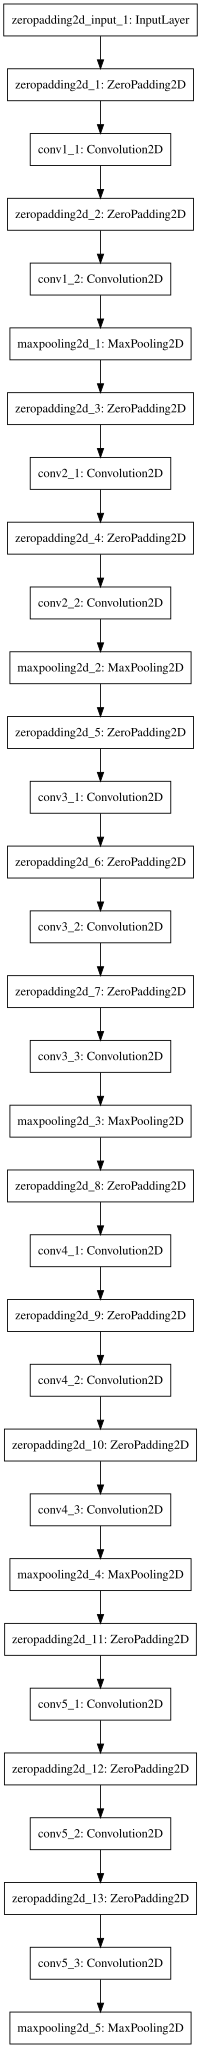

In [5]:
from IPython.display import SVG
from keras.utils.visualize_util import model_to_dot

SVG(model_to_dot(model).create(prog='dot', format='svg'))

In [ ]:
if Train_bottleneck:
    datagen = ImageDataGenerator(rescale=1./255)
    generator = datagen.flow_from_directory(
            train_data_dir,
            target_size=(img_width, img_height),
            batch_size=16,
            class_mode=None,
            shuffle=False)
    bottleneck_features_train = model.predict_generator(generator, nb_train_samples)
    np.save(open(folder+'savedmodels/bottleneck_features_train.npy', 'w'), bottleneck_features_train)

    generator = datagen.flow_from_directory(
            validation_data_dir,
            target_size=(img_width, img_height),
            batch_size=16,
            class_mode=None,
            shuffle=False)
    bottleneck_features_validation = model.predict_generator(generator, nb_validation_samples)
    np.save(open(folder+'savedmodels/bottleneck_features_validation.npy', 'w'), bottleneck_features_validation)

In [ ]:

train_data = np.load(open(folder+'savedmodels/bottleneck_features_train.npy'))
nb_train_samples = len(train_data)
# train_labels = np.array([0] * (nb_train_samples / 2) + [1] * (nb_train_samples / 2))
train_labels = []
for i in range(nb_class):
    train_labels +=  list([i] * (nb_train_samples / nb_class))
    
validation_data = np.load(open(folder+'savedmodels/bottleneck_features_validation.npy'))
nb_validation_samples = len(validation_data)
# # validation_labels = np.array([0] * (nb_validation_samples / 2) + [1] * (nb_validation_samples / 2))
validation_labels = []
for i in range(nb_class):
    validation_labels +=  list([i] * (nb_validation_samples / nb_class))

train_labels = np.array(train_labels)
validation_labels = np.array(validation_labels)
    
# print train_labels
# print validation_labels

print "Bottleneck features shape: Training set: ", train_data.shape, train_labels.shape
print "Bottleneck features shape: Validation set: ",validation_data.shape, validation_labels.shape

In [ ]:
ind_train = np.arange(len(train_data))
np.random.shuffle(ind_train)

ind_validation = np.arange(len(validation_data))
np.random.shuffle(ind_validation)

# print ind_train
# print ind_validation

train_data = train_data[ind_train]
train_labels = train_labels[ind_train]

validation_data = validation_data[ind_validation]
validation_labels = validation_labels[ind_validation]

In [ ]:
top_model = Sequential()
top_model.add(Flatten(input_shape=train_data.shape[1:]))
top_model.add(Dense(nb_filters, activation='relu'))
top_model.add(Dropout(0.5))
top_model.add(Dense(1, activation='sigmoid'))

top_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
# top_model.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=['accuracy'])

top_model.fit(train_data, train_labels,
          nb_epoch=n_epoch, batch_size=batch_size,
          validation_data=(validation_data, validation_labels))

In [ ]:
model.add(top_model)
for layer in model.layers[:25]:
    layer.trainable = False
    
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.SGD(lr=1e-4, momentum=0.9),
              metrics=['accuracy'])  
# model.compile(loss='mean_squared_error',
#               optimizer='adadelta',
#               metrics=['accuracy'])  

In [ ]:
from IPython.display import SVG
from keras.utils.visualize_util import model_to_dot

SVG(model_to_dot(model).create(prog='dot', format='svg'))

In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_data_dir,
        target_size=(img_height, img_width),
        batch_size=10,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        validation_data_dir,
        target_size=(img_height, img_width),
        batch_size=10,
        class_mode='binary')

In [ ]:
model.fit_generator(
        train_generator,
        samples_per_epoch=nb_train_samples,
        nb_epoch=10,
        validation_data=validation_generator,
        nb_val_samples=nb_validation_samples)